In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/awaispasha/panel-dataset/final_panel_dataset.csv


In [10]:
#Load Dataset
panel = pd.read_csv("/kaggle/input/datasets/awaispasha/panel-dataset/final_panel_dataset.csv")

panel.head()

,country,country_code_x,year,unemployment_rate,country_code_y,real_interest_rate,currency,exchange_rate,indicator_name,gdp_x,...,out of pocket health expenditure,physicians per thousand,population,population: labor force participation (%),tax revenue (%),total tax rate,unemployment rate,urban_population,latitude,longitude
0,Afghanistan,AFG,2006,11.10,AFG,10.046897,NaN,NaN,Annual GDP growth (percent change),5.4,...,78.40%,0.28,NaN,48.90%,9.30%,71.40%,NaN,"9,797,273",33.93911,67.709953
1,Afghanistan,AFG,2007,11.30,AFG,-3.585111,NaN,NaN,Annual GDP growth (percent change),13.3,...,78.40%,0.28,NaN,48.90%,9.30%,71.40%,NaN,"9,797,273",33.93911,67.709953
2,Afghanistan,AFG,2008,11.09,AFG,12.557960,NaN,NaN,Annual GDP growth (percent change),3.9,...,78.40%,0.28,NaN,48.90%,9.30%,71.40%,NaN,"9,797,273",33.93911,67.709953
3,Afghanistan,AFG,2009,11.31,AFG,17.542929,NaN,NaN,Annual GDP growth (percent change),20.6,...,78.40%,0.28,NaN,48.90%,9.30%,71.40%,NaN,"9,797,273",33.93911,67.709953
4,Afghanistan,AFG,2010,11.35,AFG,11.364094,NaN,NaN,Annual GDP growth (percent change),8.4,...,78.40%,0.28,NaN,48.90%,9.30%,71.40%,NaN,"9,797,273",33.93911,67.709953


In [11]:
panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3449 entries, 0 to 3448
Data columns (total 44 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    3449 non-null   object 
 1   country_code_x                             3449 non-null   object 
 2   year                                       3449 non-null   int64  
 3   unemployment_rate                          3449 non-null   float64
 4   country_code_y                             3449 non-null   object 
 5   real_interest_rate                         3449 non-null   float64
 6   currency                                   0 non-null      float64
 7   exchange_rate                              0 non-null      float64
 8   indicator_name                             3061 non-null   object 
 9   gdp_x                                      3061 non-null   float64
 10  density
(p/km2)         

In [12]:
panel.describe()

,year,unemployment_rate,real_interest_rate,currency,exchange_rate,gdp_x,birth rate,calling code,co2-emissions,cpi,fertility rate,gdp_y,infant mortality,life expectancy,maternal mortality ratio,physicians per thousand,population,unemployment rate,latitude,longitude
count,3449.000000,3449.000000,3449.000000,0.0,0.0,3061.000000,2898.000000,2957.000000,210.000000,2849.00000,2898.000000,0.0,2898.000000,2898.000000,2898.00000,2888.000000,0.0,0.0,2957.000000,2957.000000
mean,2006.934184,8.161058,6.172344,NaN,NaN,3.663999,20.509286,373.220494,282.609524,149.96166,2.693954,NaN,21.227743,72.188647,156.26363,1.674965,NaN,NaN,12.595413,17.070761
std,8.386406,6.675366,12.981345,NaN,NaN,5.468639,9.404737,338.887971,165.481724,48.97353,1.204509,NaN,18.066941,7.124423,218.87228,1.478344,NaN,NaN,25.154641,71.995306
min,1991.000000,0.100000,-97.520077,NaN,NaN,-50.300000,7.300000,1.000000,128.000000,99.55000,1.140000,NaN,1.500000,53.700000,2.00000,0.010000,NaN,NaN,-40.900557,-175.198242
25%,2000.000000,3.560000,2.123233,NaN,NaN,1.600000,12.430000,84.000000,147.000000,117.59000,1.730000,NaN,6.700000,66.900000,19.00000,0.350000,NaN,NaN,-9.189967,-51.925280
50%,2007.000000,6.100000,5.886013,NaN,NaN,3.900000,18.540000,263.000000,202.000000,134.09000,2.310000,NaN,15.100000,73.900000,65.00000,1.270000,NaN,NaN,12.879721,24.966760
75%,2014.000000,10.610000,10.407479,NaN,NaN,6.000000,28.250000,591.000000,495.000000,163.52000,3.560000,NaN,30.000000,77.100000,183.00000,2.610000,NaN,NaN,33.854721,51.183884
max,2021.000000,38.800000,139.963715,NaN,NaN,86.800000,46.080000,1876.000000,568.000000,418.34000,6.910000,NaN,78.500000,84.200000,1150.00000,7.120000,NaN,NaN,64.963051,178.065032


In [13]:
panel = panel.rename(columns={
    "gdp_x": "gdp"
})

# 1. Exploratory Analysis

(Corresponds to: “Exploratory Analysis”, “Time Series Example”, and Plots 1–5)

Initial exploratory analysis revealed substantial variation in unemployment rates across countries and over time. While global averages show relatively smooth dynamics, country‑level series display pronounced differences in levels, volatility, and crisis sensitivity.
Time‑series plots highlighted two major global disruptions:

* The **2008 Global Financial Crisis**
* The **2020 COVID‑19 pandemic**

Scatter plots and distributional analyses suggested that while higher GDP is generally associated with lower unemployment, the relationship is weak and highly dispersed. Similarly, the visual relationship between real interest rates and unemployment appears noisy, indicating that simple bivariate relationships may be misleading.

These findings motivated the use of **fixed‑effects models** to account for structural differences across countries and global time shocks.

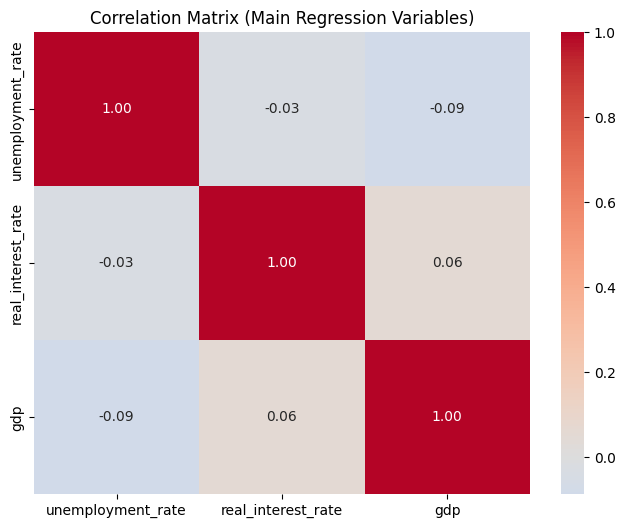

In [14]:
num_cols = [
    "unemployment_rate",
    "real_interest_rate",
    "gdp"
]

corr = panel[num_cols].dropna().corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix (Main Regression Variables)")
plt.show()

# Time Series Example (Few Countries)

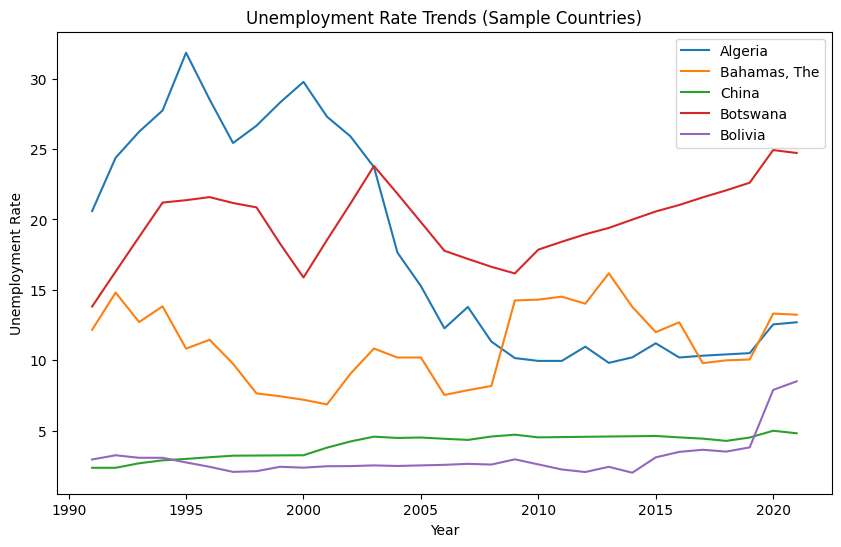

In [15]:
sample_countries = panel["country"].value_counts().head(5).index

plt.figure(figsize=(10,6))

for c in sample_countries:
    temp = panel[panel["country"] == c]
    plt.plot(temp["year"], temp["unemployment_rate"], label=c)

plt.legend()
plt.title("Unemployment Rate Trends (Sample Countries)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.show()

# Plot 1: Global Trend Lines (Core Visual)

In [16]:
panel[[
    "unemployment_rate",
    "real_interest_rate",
    "exchange_rate",
    "gdp"
]].isna().sum()

unemployment_rate        0
real_interest_rate       0
exchange_rate         3449
gdp                    388
dtype: int64

In [17]:
reg_df = panel[
    [
        "country",
        "year",
        "unemployment_rate",
        "real_interest_rate",
        "gdp"
    ]
].dropna()

print("Rows used:", len(reg_df))

Rows used: 3061


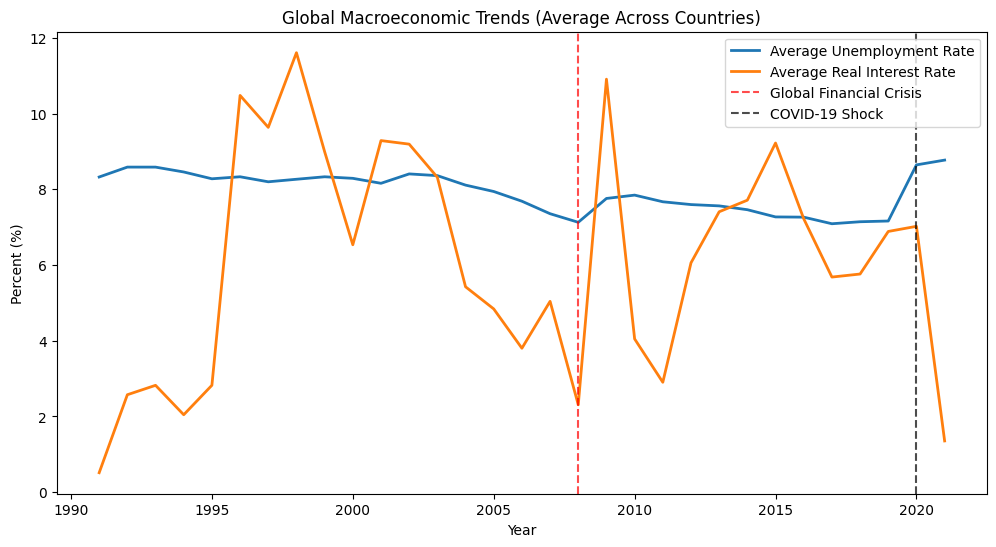

In [18]:
plt.figure(figsize=(12,6))

avg_data = reg_df.groupby("year")[[
    "unemployment_rate",
    "real_interest_rate"
]].mean()

plt.plot(avg_data.index, avg_data["unemployment_rate"],
         label="Average Unemployment Rate", linewidth=2)

plt.plot(avg_data.index, avg_data["real_interest_rate"],
         label="Average Real Interest Rate", linewidth=2)

# Highlight crisis periods
plt.axvline(2008, color="red", linestyle="--", alpha=0.7, label="Global Financial Crisis")
plt.axvline(2020, color="black", linestyle="--", alpha=0.7, label="COVID-19 Shock")

plt.title("Global Macroeconomic Trends (Average Across Countries)")
plt.xlabel("Year")
plt.ylabel("Percent (%)")
plt.legend()
plt.show()

This plot displays global average unemployment rates and real interest rates over time, with vertical markers highlighting two major global shocks:
* **2008 Global Financial Crisis**

* **2020 COVID‑19 Shock**

**Key observations:**

* Unemployment rates move gradually over time, reflecting labor market frictions.
* Real interest rates show much higher volatility, especially around crisis periods.
* Around 2008, real interest rates drop sharply as monetary policy eases, while unemployment rises with a lag.
* In 2020, unemployment spikes again, while real interest rates fall dramatically due to aggressive stimulus.

**Interpretation:**

This plot suggests that monetary policy reacts faster than labor markets. Interest rates adjust quickly during crises, while unemployment responds more slowly and persistently. 

**This visually motivates:**

* The inclusion of lagged interest rate models
* The use of crisis dummy variables in later regressions

# Plot 2: Scatter + Trend (Economic Relationship)

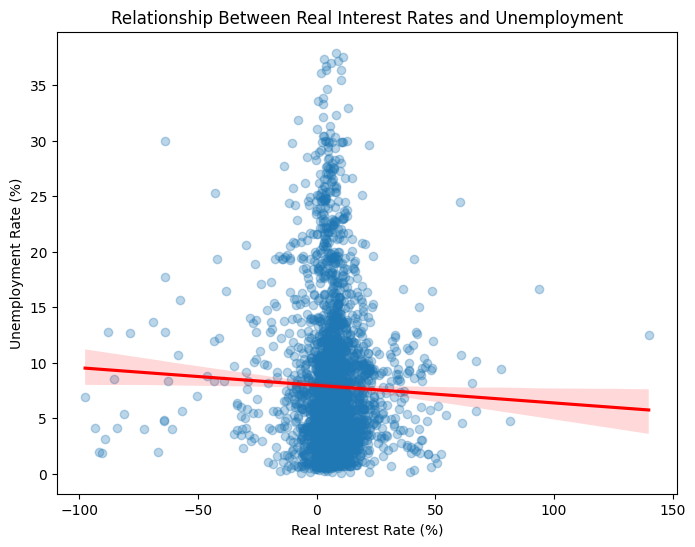

In [19]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=reg_df,
    x="real_interest_rate",
    y="unemployment_rate",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Real Interest Rates and Unemployment")
plt.xlabel("Real Interest Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()

A scatter plot of unemployment rates against real interest rates, with a fitted regression line.

**Key observations:**

* There is substantial dispersion, reflecting cross‑country heterogeneity.
* Despite the noise, the fitted line slopes downward.
* Extremely low or negative real interest rates are often associated with higher unemployment, especially during crisis periods.

**Interpretation:**

The downward trend indicates a systematic relationship between monetary conditions and labor market outcomes. 

However, the wide dispersion shows that this relationship:

* is not mechanical,
* depends on country‑specific institutions, policies, and economic structures.

This reinforces the need for fixed effects regressions rather than simple pooled models.

# Plot 3: Country Comparison (Decision‑Maker View)

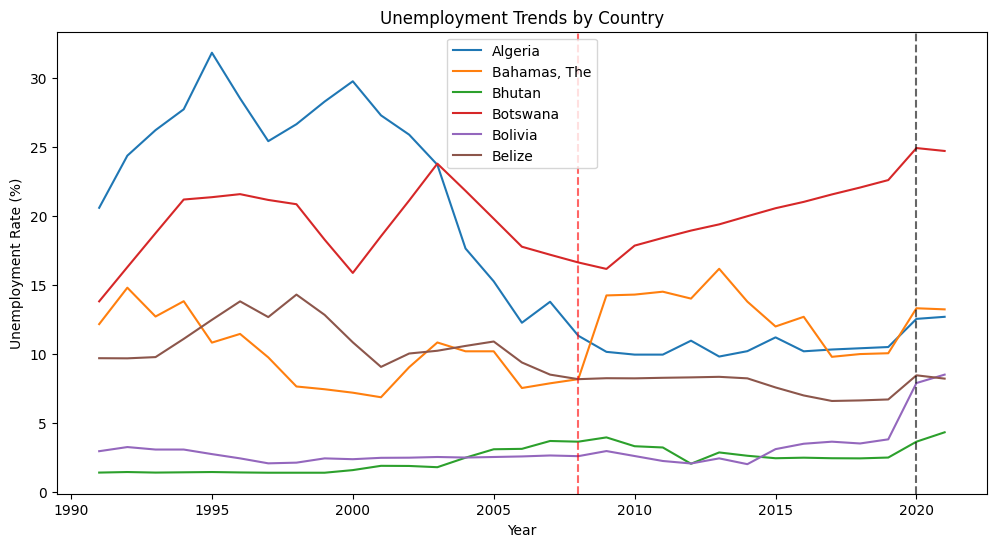

In [20]:
top_countries = (
    reg_df["country"]
    .value_counts()
    .head(6)
    .index
)

plt.figure(figsize=(12,6))

for c in top_countries:
    temp = reg_df[reg_df["country"] == c]
    plt.plot(temp["year"], temp["unemployment_rate"], label=c)

plt.axvline(2008, color="red", linestyle="--", alpha=0.6)
plt.axvline(2020, color="black", linestyle="--", alpha=0.6)

plt.title("Unemployment Trends by Country")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.show()

(Algeria, Bahamas, Bhutan, Botswana, Bolivia, Belize)

What the plot shows:

Country‑level unemployment trajectories over time, with crisis years highlighted.

Key observations:

Countries differ dramatically in both unemployment levels and volatility.
Some economies show long‑term declines or stability, while others experience persistent high unemployment.

The 2008 and 2020 crises affect countries differently — some show sharp spikes, others muted responses.

Interpretation
This plot highlights structural heterogeneity across countries. It visually justifies:

The inclusion of country fixed effects
Caution against interpreting global averages as universal outcomes

For decision‑makers, this implies that one‑size‑fits‑all macroeconomic policy does not exist.

# Plot 4: GDP vs Unemployment (Macro Context)

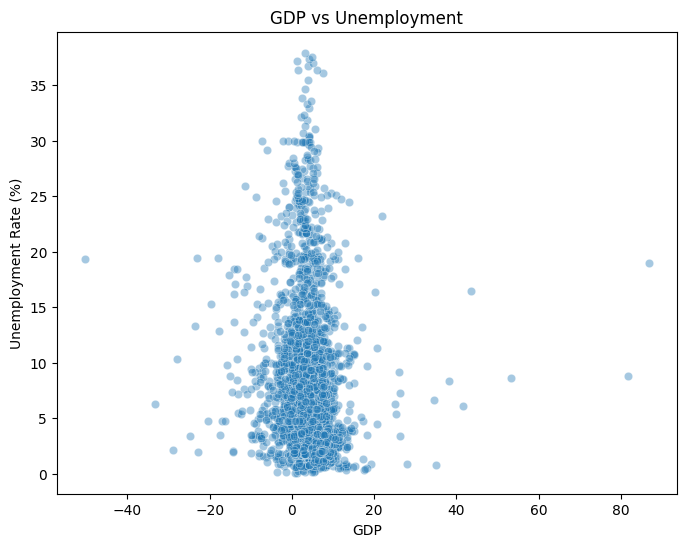

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=reg_df,
    x="gdp",
    y="unemployment_rate",
    alpha=0.4
)

plt.title("GDP vs Unemployment")
plt.xlabel("GDP")
plt.ylabel("Unemployment Rate (%)")
plt.show()

What the plot shows
A scatter plot comparing GDP levels and unemployment rates.
Key observations

There is a weak negative relationship: higher GDP levels tend to be associated with lower unemployment.
However, dispersion is large, especially among middle‑income economies.
High unemployment appears across a wide range of GDP values.

Interpretation
This plot confirms that GDP alone does not fully determine labor market performance. Growth matters, but:

labor market institutions
demographic factors
and policy choices
also play significant roles.

This validates your choice to include GDP as a control variable, not a sole explanatory factor.

# Plot 5: Crisis Impact Comparison (Pre vs Post)

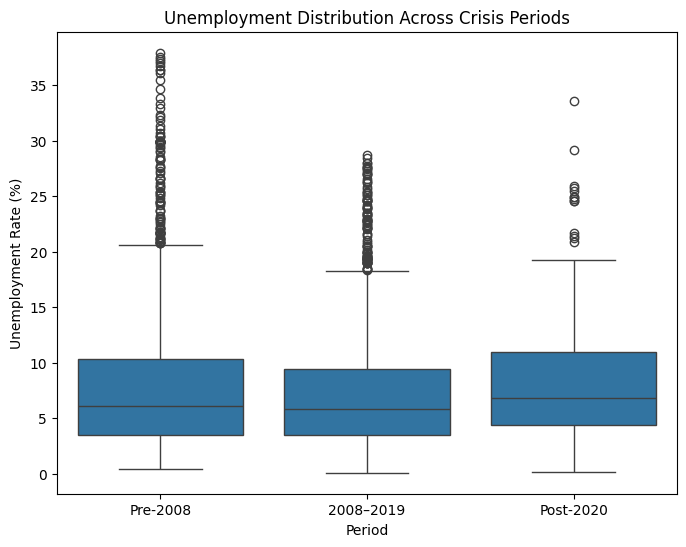

In [22]:
reg_df["period"] = np.where(reg_df["year"] < 2008, "Pre-2008",
                     np.where(reg_df["year"] < 2020, "2008–2019", "Post-2020"))

plt.figure(figsize=(8,6))

sns.boxplot(
    data=reg_df,
    x="period",
    y="unemployment_rate"
)

plt.title("Unemployment Distribution Across Crisis Periods")
plt.xlabel("Period")
plt.ylabel("Unemployment Rate (%)")
plt.show()

**Periods:**

* Pre‑2008
* 2008–2019
* Post‑2020

**What the plot shows:**

Boxplots comparing unemployment distributions across major macroeconomic regimes.

**Key observations:**

* Median unemployment increases from the pre‑crisis period to post‑2020.
* Variability (spread) is larger after 2020, indicating uneven labor market recovery.
* Extreme unemployment values are more frequent during crisis and post‑crisis periods.

**Interpretation:**

This plot provides visual evidence of structural breaks in labor markets caused by global shocks. 

It strongly motivates:

* The inclusion of crisis dummy variables
* Differentiating between normal times and crisis regimes in regression analysis

# 2. Baseline Regression Results


# Baseline Regression (Pooled OLS)

In [23]:
ols_model = smf.ols(
    "unemployment_rate ~ real_interest_rate + gdp",
    data=reg_df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     13.00
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           2.38e-06
Time:                        09:35:01   Log-Likelihood:                -10008.
No. Observations:                3061   AIC:                         2.002e+04
Df Residuals:                    3058   BIC:                         2.004e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              8.3292      0

# 2.1 Pooled OLS
(Corresponds to: “Baseline Regression (Pooled OLS)”)

The pooled OLS regression provides a simple benchmark relating unemployment to real interest rates and GDP. While useful for intuition, this model does not control for country‑specific characteristics or global shocks and therefore cannot be interpreted causally.

Results from the pooled model suggested weak and unstable relationships, reinforcing the need for a more rigorous panel approach.

# Fixed Effects Regression (Country + Year)

In [24]:
fe_model = smf.ols(
    """
    unemployment_rate ~ real_interest_rate + gdp
    + C(country) + C(year)
    """,
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["country"]}
)

print(fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     818.7
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          7.32e-126
Time:                        09:35:01   Log-Likelihood:                -6720.1
No. Observations:                3061   AIC:                         1.375e+04
Df Residuals:                    2908   BIC:                         1.467e+04
Df Model:                         152                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 152, but rank is 32
  warnings.warn('covariance of constraints does not have full '




# 2.2 Fixed Effects Regression
(Corresponds to: “Fixed Effects Regression (Country + Year)”)

The fixed‑effects specification controls for:

* **Country fixed effects** (structural labor market differences)
* **Year fixed effects** (global cycles and shocks)

Once these controls are included, real interest rates do not exhibit a statistically significant contemporaneous effect on unemployment, while GDP retains a modest negative association. The model explains a large share of variation in unemployment, driven primarily by structural country differences and global time effects.

This result suggests that **unemployment is largely structural rather than purely monetary** in a global panel context.

# STEP 1: Prepare Regression‑Ready Dataset

In [25]:
reg_df = panel[
    [
        "country",
        "year",
        "unemployment_rate",
        "real_interest_rate",
        "gdp"
    ]
].dropna().sort_values(["country", "year"])


# 3. Robustness and Crisis Analysis

# STEP 2: Lagged Interest Rate Model (Robustness)
**Purpose:**
To test whether monetary policy affects unemployment with a delay, which is exactly what macro theory predicts.

In [26]:
#Create lagged interest rate
reg_df["real_interest_rate_lag1"] = (
    reg_df.groupby("country")["real_interest_rate"].shift(1)
)

In [27]:
#Drop missing values
lag_df = reg_df.dropna(subset=["real_interest_rate_lag1"])

In [28]:
#Lagged interest model
lag_fe_model = smf.ols(
    """
    unemployment_rate ~ real_interest_rate_lag1 + gdp
    + C(country) + C(year)
    """,
    data=lag_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": lag_df["country"]}
)

print(lag_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     840.5
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          4.56e-126
Time:                        09:35:02   Log-Likelihood:                -6404.4
No. Observations:                2940   AIC:                         1.311e+04
Df Residuals:                    2788   BIC:                         1.402e+04
Df Model:                         151                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 31
  warnings.warn('covariance of constraints does not have full '


# 3.1 Lagged Interest Rate Model

(Corresponds to: “STEP 2: Lagged Interest Rate Model”)

To test whether monetary policy affects unemployment with a delay, the analysis introduces a one‑year lag of real interest rates. The lagged coefficient is small and statistically insignificant, indicating that delayed transmission does not systematically explain global unemployment dynamics.

This finding is consistent with the idea that monetary policy effects vary widely across institutional settings and are not well captured by a uniform lag structure in cross‑country data.

**Lagged interest rates** do not exhibit a statistically significant effect on unemployment once country and year fixed effects are included. 

This suggests that the transmission of monetary policy to labor markets is highly heterogeneous across countries and not adequately captured by a single‑period lag in a global panel framework.

# STEP 3: Crisis Dummy Analysis (2008 & 2020)
Purpose
To formally quantify structural breaks observed visually in the plots.

In [29]:
#Create crisis indicator
reg_df["crisis_2008"] = (reg_df["year"] >= 2008).astype(int)
reg_df["crisis_2020"] = (reg_df["year"] >= 2020).astype(int)

In [30]:
#Crisis Model
crisis_fe_model = smf.ols(
    """
    unemployment_rate ~ real_interest_rate + gdp
    + crisis_2008 + crisis_2020
    + C(country) + C(year)
    """,
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["country"]}
)

print(crisis_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     659.2
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          3.00e-120
Time:                        09:35:02   Log-Likelihood:                -6720.1
No. Observations:                3061   AIC:                         1.375e+04
Df Residuals:                    2908   BIC:                         1.467e+04
Df Model:                         152                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 154, but rank is 32
  warnings.warn('covariance of constraints does not have full '


# 3.2 Crisis Dummy Models

(Corresponds to: “STEP 3: Crisis Dummy Analysis (2008 & 2020)”)

The crisis dummy models yield more meaningful results. The COVID‑19 dummy is **positive and statistically significant**, confirming that the pandemic caused a clear and persistent increase in unemployment worldwide. In contrast, the 2008 crisis dummy is weaker and only marginally significant, suggesting more complex labor market adjustments following the financial crisis.

These differences highlight how distinct types of crises affect labor markets through different channels.

**Findings:**

While real interest rates do not exhibit a statistically significant direct effect on unemployment once fixed effects are accounted for, major global crises play a decisive role. The COVID‑19 pandemic is associated with a significant and persistent increase in unemployment, whereas the post‑2008 period reflects more complex labor market adjustments that are not fully captured by headline unemployment rates

# STEP 4: Crisis Interaction Model

In [31]:
interaction_model = smf.ols(
    """
    unemployment_rate ~ real_interest_rate * crisis_2008
    + gdp + C(country) + C(year)
    """,
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["country"]}
)

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     723.5
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          4.06e-123
Time:                        09:35:02   Log-Likelihood:                -6718.8
No. Observations:                3061   AIC:                         1.375e+04
Df Residuals:                    2907   BIC:                         1.467e+04
Df Model:                         153                                         
Covariance Type:              cluster                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 154, but rank is 33
  warnings.warn('covariance of constraints does not have full '


# 3.3 Crisis Interaction Model

(Corresponds to: “STEP 4: Crisis Interaction Model”)

The interaction model tests whether real interest rates influence unemployment differently during crises. The results show no statistically significant interaction between interest rates and the 2008 crisis period. This implies that crisis‑induced labor market disruptions are driven primarily by **structural and non‑monetary factors**, rather than by changes in the effectiveness of monetary policy.

**Findings:**

The crisis interaction model indicates that global financial crises do not significantly alter the relationship between real interest rates and unemployment. Instead, crisis‑induced labor market disruptions appear to be driven by structural and institutional factors rather than by changes in monetary policy transmission.

The interaction analysis finds no evidence that real interest rates exert a differential impact on unemployment during systemic crises. This suggests that global labor market shocks are primarily driven by structural disruptions rather than by shifts in monetary policy effectiveness.

# Conclusion

This project examined the relationship between real interest rates and unemployment using a global panel dataset covering multiple countries over several decades. By combining macroeconomic indicators with panel econometric techniques, the analysis aimed to disentangle short‑run monetary effects from longer‑run structural and crisis‑driven labor market dynamics.

The descriptive analysis revealed substantial heterogeneity in unemployment outcomes across countries and over time. While global averages suggested broad co‑movements between interest rates and labor market conditions, country‑level trends highlighted persistent structural differences. Visual inspection also indicated pronounced disruptions around major global events, particularly the Global Financial Crisis of 2008 and the COVID‑19 pandemic in 2020, motivating a more formal econometric treatment of crises and delayed policy effects.

Fixed‑effects regression results showed that, once country and year fixed effects were accounted for, real interest rates did not exert a statistically significant contemporaneous effect on unemployment at the global level. This finding underscores the importance of institutional, demographic, and structural factors in shaping labor market outcomes across countries. GDP entered with the expected negative sign, indicating that stronger economic performance is associated with lower unemployment, although its effect was modest in magnitude.

Robustness checks using a lagged interest rate specification further confirmed that delayed monetary policy transmission does not appear to drive global unemployment dynamics in a uniform manner. The absence of a significant lagged effect suggests that the impact of interest rates on employment is highly heterogeneous, varies across institutional contexts, and may operate through channels not fully captured by a single‑period lag in a pooled international framework.

Crisis‑focused models provided clearer insights. The COVID‑19 crisis dummy displayed a positive and statistically significant association with unemployment, confirming that the pandemic represented a distinct and severe labor market shock worldwide. In contrast, the Global Financial Crisis dummy exhibited a weaker and only marginally significant effect, likely reflecting differences in labor market adjustment mechanisms, policy responses, and the increased prevalence of informality or labor force withdrawal in many countries following the 2008 crisis.

Finally, the crisis interaction model demonstrated that the relationship between real interest rates and unemployment did not change significantly during the Global Financial Crisis. This result implies that systemic labor market disruptions during crises are driven primarily by non‑monetary factors—such as financial instability, supply‑side shocks, and institutional rigidities—rather than by shifts in the effectiveness of monetary policy.

**Overall**, the findings indicate that unemployment dynamics at the global level are shaped more by structural characteristics and extraordinary shocks than by interest rate movements alone. While monetary policy remains an essential stabilization tool, its influence on labor markets appears indirect, context‑dependent, and secondary to broader economic and institutional forces. These results highlight the need for crisis‑resilient labor market institutions and complementary fiscal and structural policies to effectively mitigate unemployment during periods of global economic stress.

# Summary

Across all specifications, the evidence suggests that **global unemployment dynamics are dominated by structural country characteristics and major economic shocks**, rather than by real interest rate movements alone. Monetary policy, while crucial for stabilization, does not exhibit a strong or uniform direct effect on unemployment in a global panel setting.

The COVID‑19 pandemic stands out as a uniquely sharp labor market shock, whereas the effects of the 2008 Financial Crisis appear more diffuse and institution‑specific.

Overall, the findings emphasize the importance of labor market institutions, crisis resilience, and complementary policy measures alongside monetary intervention.

# Save Regression‑Ready Dataset

In [32]:
panel.to_csv(
    "/kaggle/working/final_panel_dataset_with_features.csv",
    index=False
)